In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set seaborn style for better visuals
sns.set(style="whitegrid")

# Define the directory where CSV files are saved
INPUT_DIR = Path("request_traces")  # Adjust if needed, assuming relative to notebook

# List of trace types
TRACE_TYPES = ["static", "normal", "poisson", "synthetic"]
YEAR = 2024

In [2]:
# Function to load a trace CSV
def load_trace(trace_type: str) -> pd.DataFrame:
    file_path = INPUT_DIR / f"{trace_type}_requests_{YEAR}.csv"
    df = pd.read_csv(file_path)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df.set_index('timestamp', inplace=True)
    return df

In [3]:
# Load all traces into a dictionary
traces = {trace_type: load_trace(trace_type) for trace_type in TRACE_TYPES}

# Display the first few rows of each trace
for trace_type, df in traces.items():
    print(f"\n{trace_type.capitalize()} Trace Head:")
    display(df.head())


Static Trace Head:


,requests
timestamp,
2024-01-01 00:00:00,1000
2024-01-01 01:00:00,1000
2024-01-01 02:00:00,1000
2024-01-01 03:00:00,1000
2024-01-01 04:00:00,1000



Normal Trace Head:


,requests
timestamp,
2024-01-01 00:00:00,1101
2024-01-01 01:00:00,654
2024-01-01 02:00:00,1250
2024-01-01 03:00:00,1313
2024-01-01 04:00:00,350



Poisson Trace Head:


,requests
timestamp,
2024-01-01 00:00:00,993
2024-01-01 01:00:00,1035
2024-01-01 02:00:00,1042
2024-01-01 03:00:00,999
2024-01-01 04:00:00,956



Synthetic Trace Head:


,requests
timestamp,
2024-01-01 00:00:00,1047
2024-01-01 01:00:00,1101
2024-01-01 02:00:00,1249
2024-01-01 03:00:00,1023
2024-01-01 04:00:00,1178


In [4]:
# Compute summary statistics for each trace
for trace_type, df in traces.items():
    print(f"\n{trace_type.capitalize()} Trace Summary Statistics:")
    display(df.describe())


Static Trace Summary Statistics:


,requests
count,8784.0
mean,1000.0
std,0.0
min,1000.0
25%,1000.0
50%,1000.0
75%,1000.0
max,1000.0



Normal Trace Summary Statistics:


,requests
count,8784.000000
mean,997.956512
std,332.540446
min,0.000000
25%,777.000000
50%,998.000000
75%,1216.000000
max,2341.000000



Poisson Trace Summary Statistics:


,requests
count,8784.000000
mean,1000.424977
std,31.447421
min,882.000000
25%,979.000000
50%,1000.000000
75%,1021.000000
max,1116.000000



Synthetic Trace Summary Statistics:


,requests
count,8784.000000
mean,1004.920423
std,540.352632
min,0.000000
25%,595.000000
50%,1002.000000
75%,1406.000000
max,2359.000000


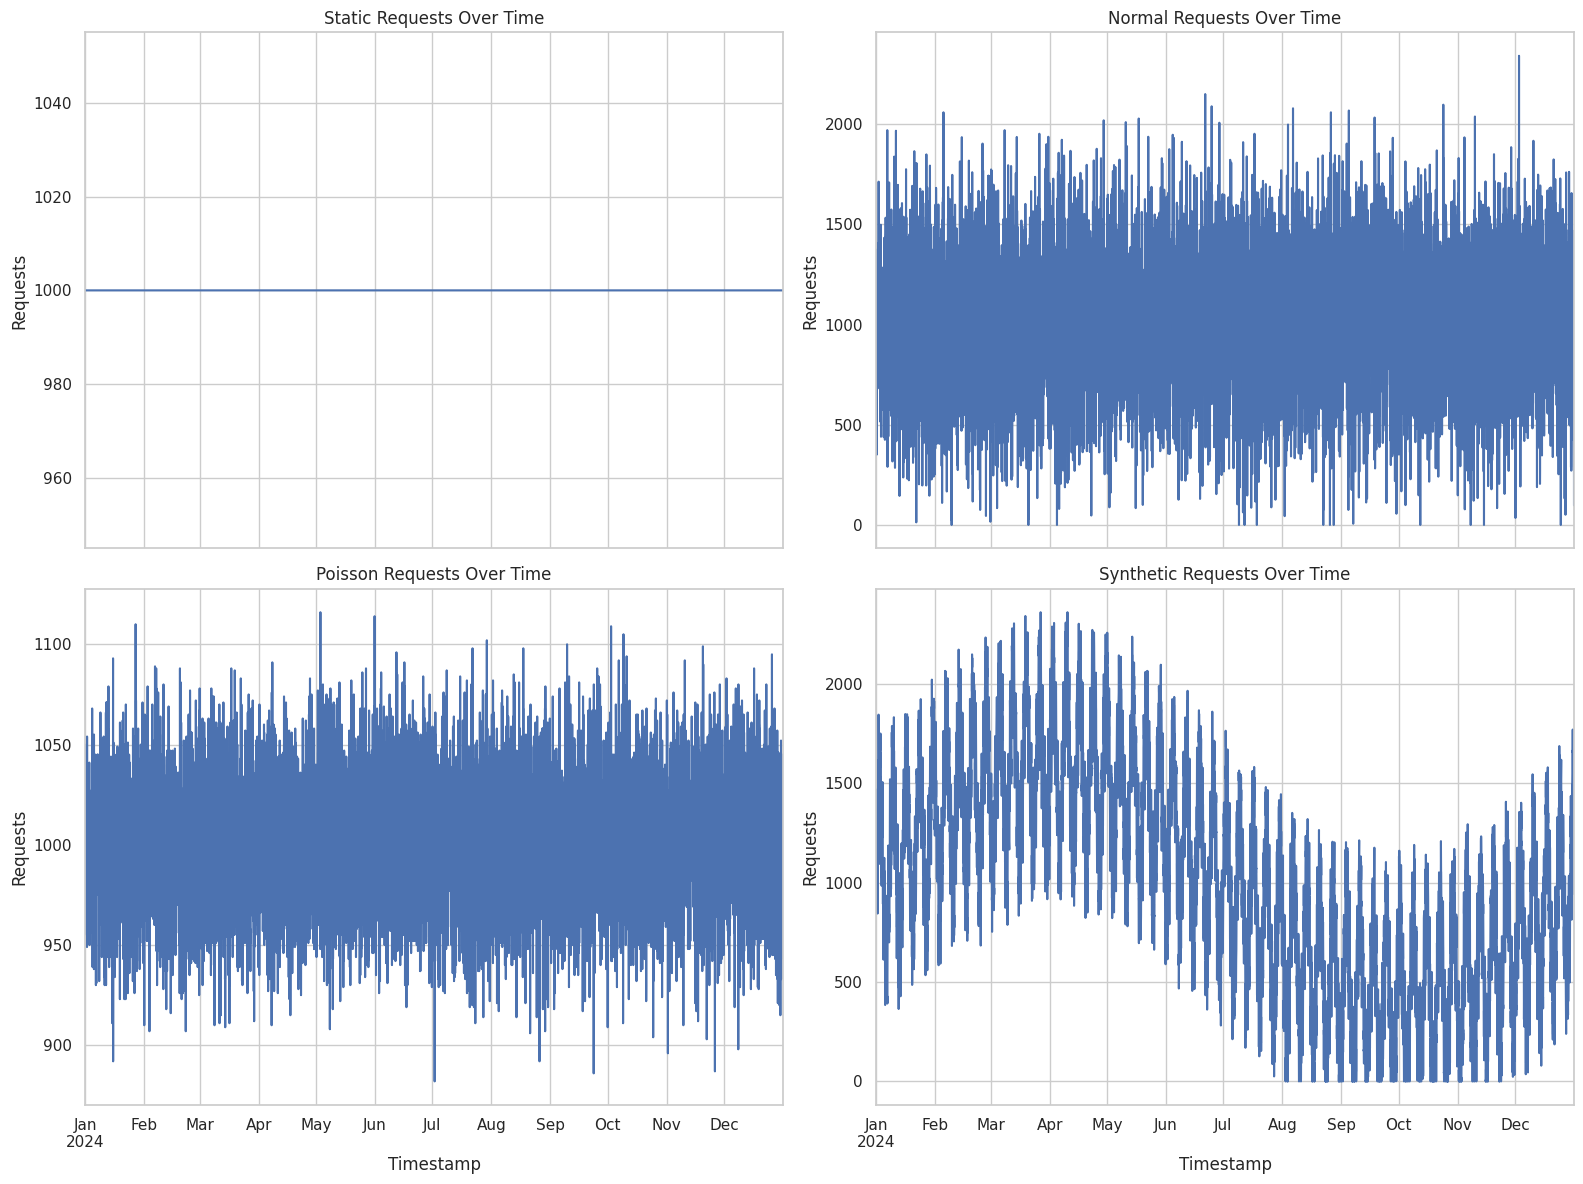

In [5]:
# Plot time series for each trace
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=False)
axes = axes.flatten()

for i, (trace_type, df) in enumerate(traces.items()):
    ax = axes[i]
    df['requests'].plot(ax=ax, title=f"{trace_type.capitalize()} Requests Over Time")
    ax.set_ylabel("Requests")
    ax.set_xlabel("Timestamp")

plt.tight_layout()
plt.show()

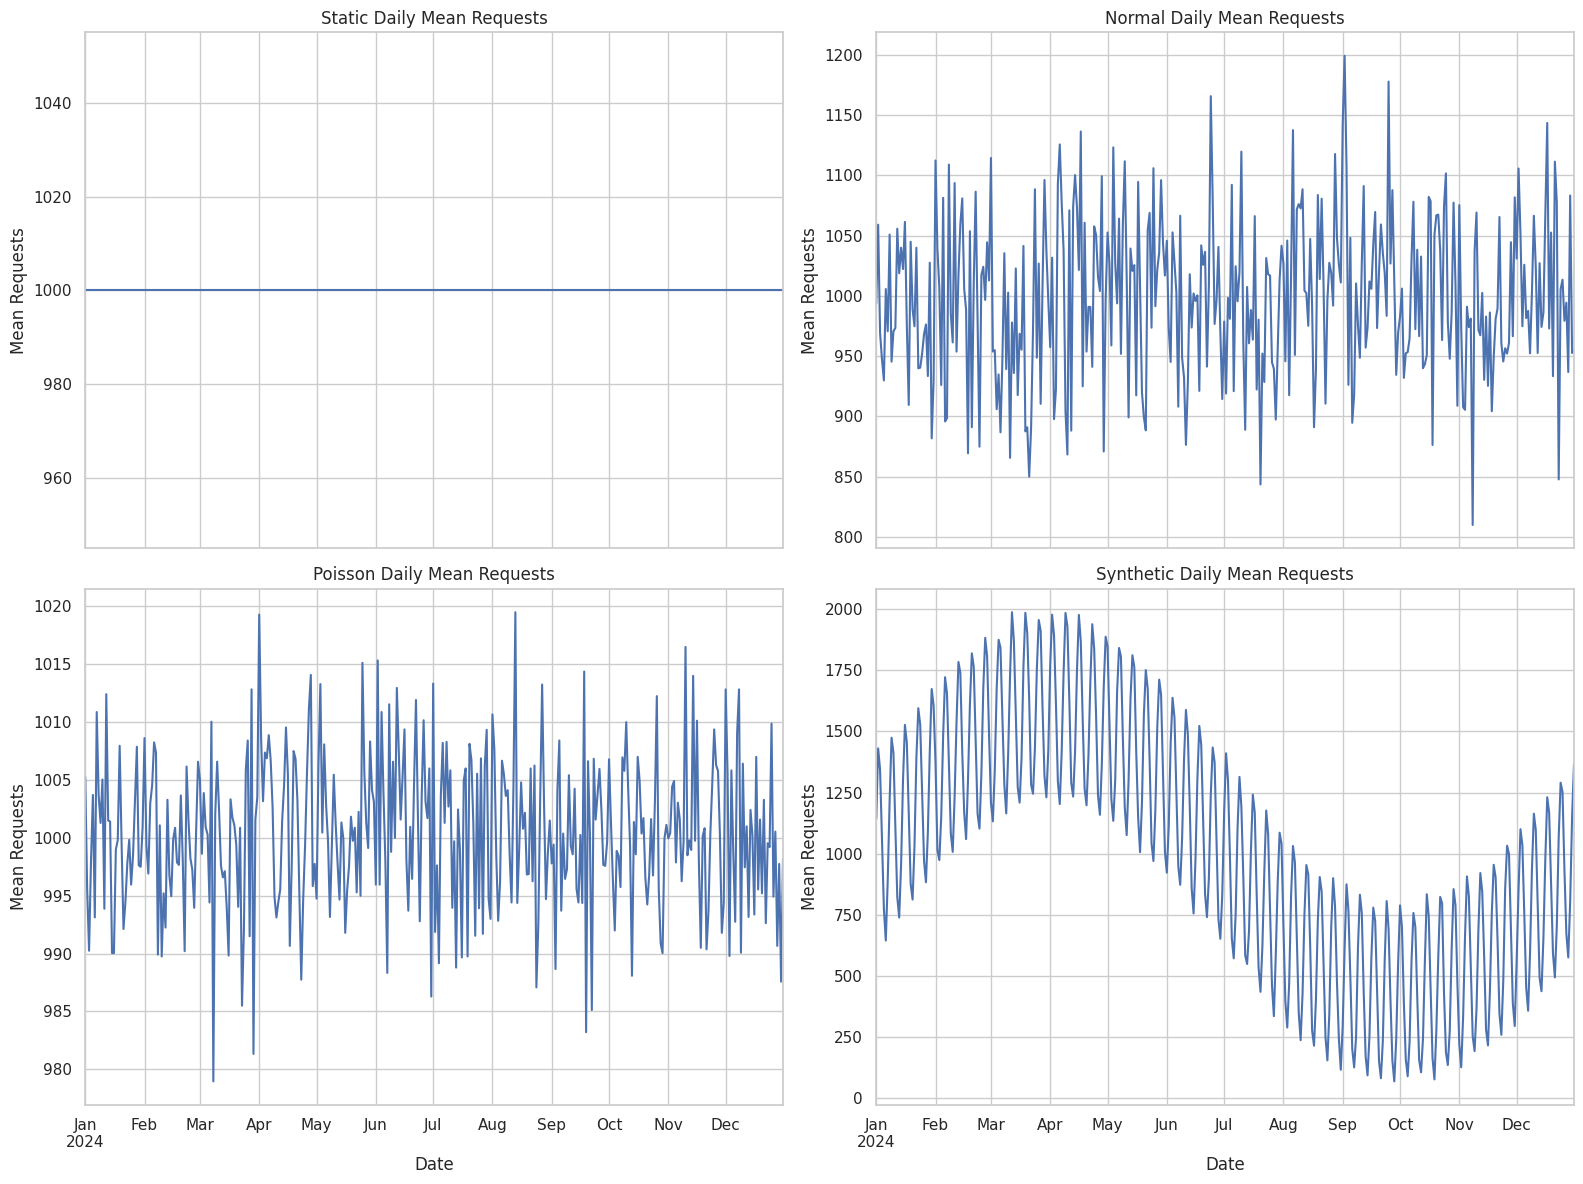

In [6]:
# To handle the density of hourly data, resample to daily mean and plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=False)
axes = axes.flatten()

for i, (trace_type, df) in enumerate(traces.items()):
    ax = axes[i]
    daily = df.resample('D').mean()
    daily['requests'].plot(ax=ax, title=f"{trace_type.capitalize()} Daily Mean Requests")
    ax.set_ylabel("Mean Requests")
    ax.set_xlabel("Date")

plt.tight_layout()
plt.show()

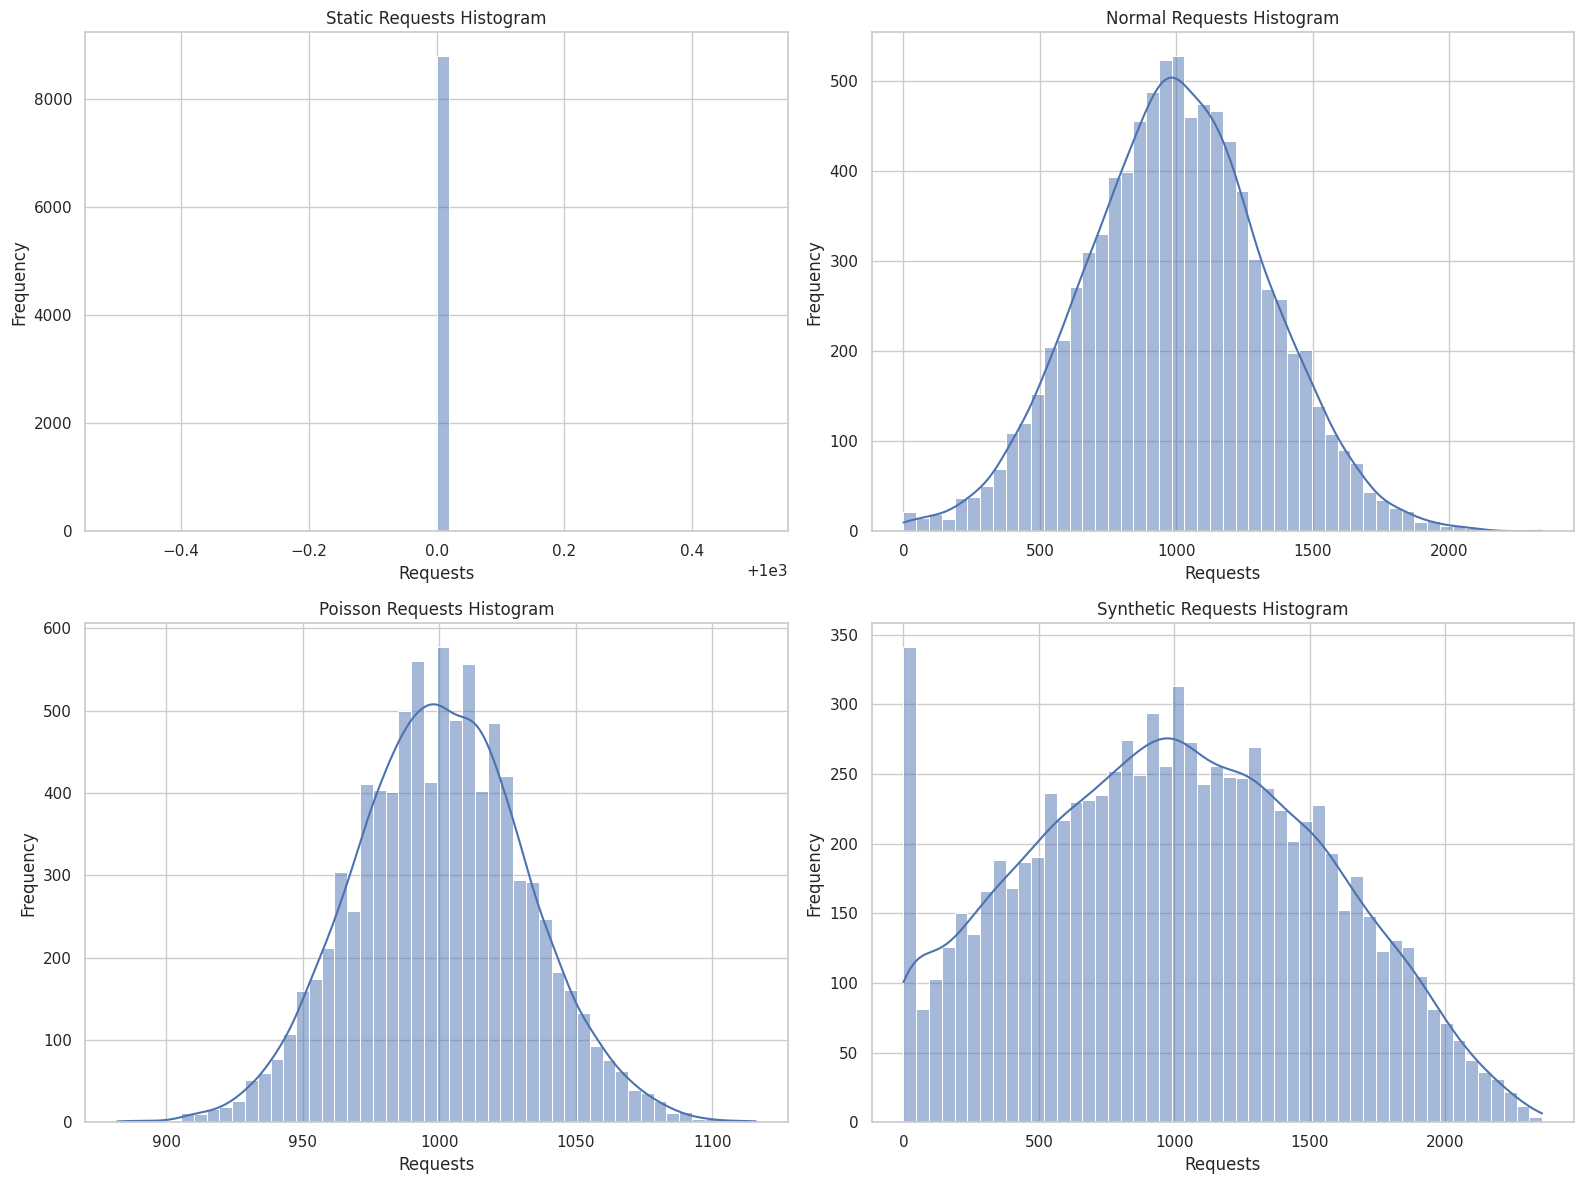

In [7]:
# Plot histograms for each trace to show distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=False, sharey=False)
axes = axes.flatten()

for i, (trace_type, df) in enumerate(traces.items()):
    ax = axes[i]
    sns.histplot(df['requests'], bins=50, kde=True, ax=ax)
    ax.set_title(f"{trace_type.capitalize()} Requests Histogram")
    ax.set_xlabel("Requests")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

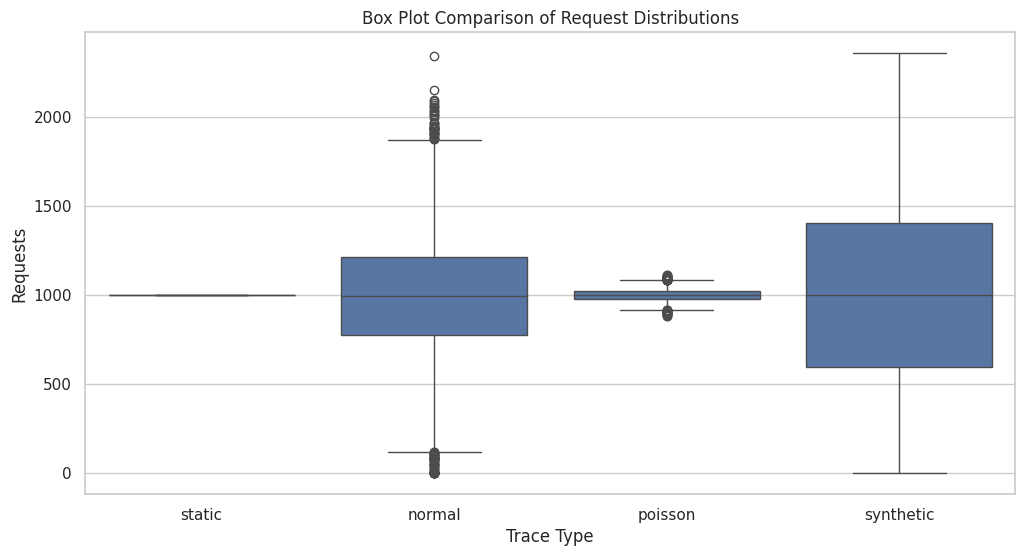

In [8]:
# Box plots to compare distributions across traces
all_data = pd.concat([df.assign(trace=trace_type) for trace_type, df in traces.items()])

plt.figure(figsize=(12, 6))
sns.boxplot(x='trace', y='requests', data=all_data)
plt.title("Box Plot Comparison of Request Distributions")
plt.xlabel("Trace Type")
plt.ylabel("Requests")
plt.show()

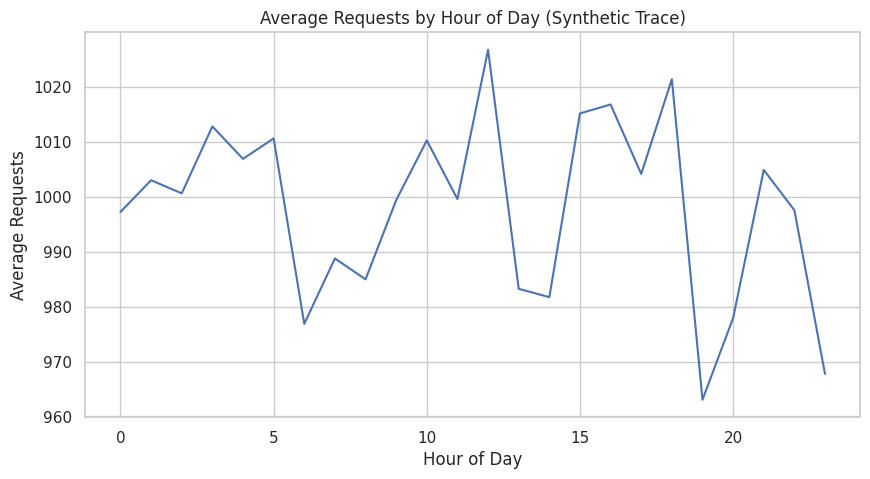

In [12]:
# For synthetic trace, analyze cycles (e.g., daily pattern)
synthetic = traces['normal']

# Group by hour of day and compute mean
synthetic['hour'] = synthetic.index.hour
daily_pattern = synthetic.groupby('hour')['requests'].mean()

plt.figure(figsize=(10, 5))
daily_pattern.plot(kind='line')
plt.title("Average Requests by Hour of Day (Synthetic Trace)")
plt.xlabel("Hour of Day")
plt.ylabel("Average Requests")
plt.show()

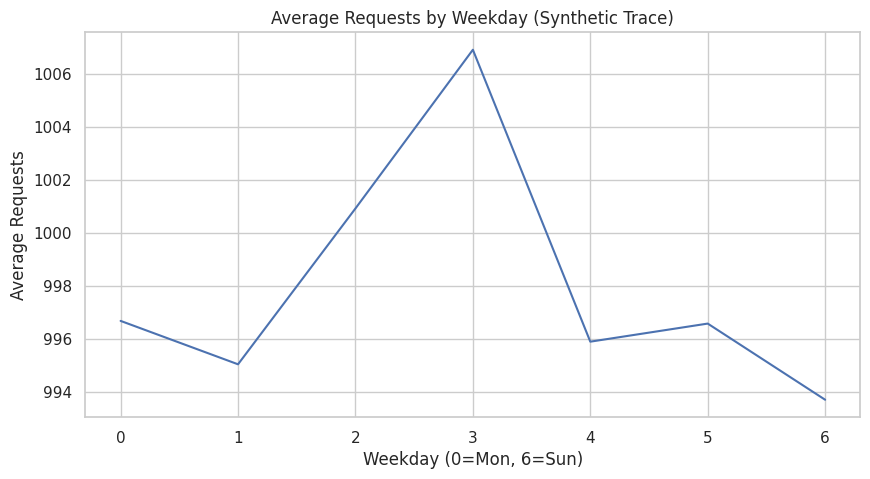

In [13]:
# Similarly, weekly pattern
synthetic['weekday'] = synthetic.index.weekday
weekly_pattern = synthetic.groupby('weekday')['requests'].mean()

plt.figure(figsize=(10, 5))
weekly_pattern.plot(kind='line')
plt.title("Average Requests by Weekday (Synthetic Trace)")
plt.xlabel("Weekday (0=Mon, 6=Sun)")
plt.ylabel("Average Requests")
plt.show()